In [1]:
import numpy as np
import sympy as smp
from scipy.integrate import odeint, trapz
import matplotlib.pyplot as plt
import math

In [2]:
t,m, m2, g, g2, A, u = smp.symbols('t m m2 g g2 A u')
S, I, R, lam1, lam2 = smp.symbols('S I R lam1 lam2', cls=smp.Function)
S = S(t)
I = I(t)
R = R(t)
lam1 = lam1(t)
lam2 = lam2(t)
I_d = smp.diff(I, t)
S_d = smp.diff(S, t)
R_d = smp.diff(R, t)
lam1_d = smp.diff(lam1, t)
lam2_d = smp.diff(lam2, t)

In [3]:
S_d = -m2*S*I - (lam1 * S / A)*S
I_d = m2*S*I - g2*I
R_d = g2*I + (lam1 * S/A)*S
lam1_d = lam1*(m2*I + lam1*S/A) - lam2*m2*I 
lam2_d = -1 + lam1*m2*S - lam2*(m2*S - g2)

S_f2 = smp.lambdify([m2, A, S,I, lam1], S_d)
I_f2 = smp.lambdify([m2, g2, S,I], I_d)
R_f2 = smp.lambdify([A, g2, S, I, lam1], R_d)
lam1_f = smp.lambdify([m2, A, S, I, lam1, lam2], lam1_d)
lam2_f = smp.lambdify([m2, g2, S, lam1, lam2], lam2_d)

In [4]:
def sol2(W, t):
    return [
        S_f2(m2, A, W[0], W[1], W[3]),
        I_f2(m2, g2, W[0], W[1]),
        R_f2(A, g2, W[0], W[1], W[3]),
        lam1_f(m2, A, W[0], W[1], W[3], W[4]),
        lam2_f(m2, g2, W[1], W[3], W[4])
    ] 

In [5]:
t = np.linspace(0, 40, 1000)
m2 = 0.77
A = 5000 
g2 = 1/3 
solution1 = odeint(sol2, [0.99, 0.01, 0.01, 0.01, 0.01], t)

In [6]:
index_s = np.where(solution1.T[1] > 0)
values_S = solution1.T[0][index_s]
values_I = solution1.T[1][index_s]
values_R = solution1.T[2][index_s]
values_lam1 = solution1.T[3][index_s]
t_true = t[index_s]

In [7]:
func_opt = values_lam1*values_S/A

In [8]:
S_d = -m*S*I - u*S
I_d = m*S*I - g*I
R_d = g*I + u*S

S_f = smp.lambdify([m, u, S,I], S_d)
I_f = smp.lambdify([m, g, S,I], I_d)
R_f = smp.lambdify([g, u,S, I], R_d)

In [9]:
def sol(W, t):
    return [
        S_f(m, u, W[0], W[1]),
        I_f(m, g, W[0], W[1]),
        R_f(g, u, W[0], W[1]),
    ] 

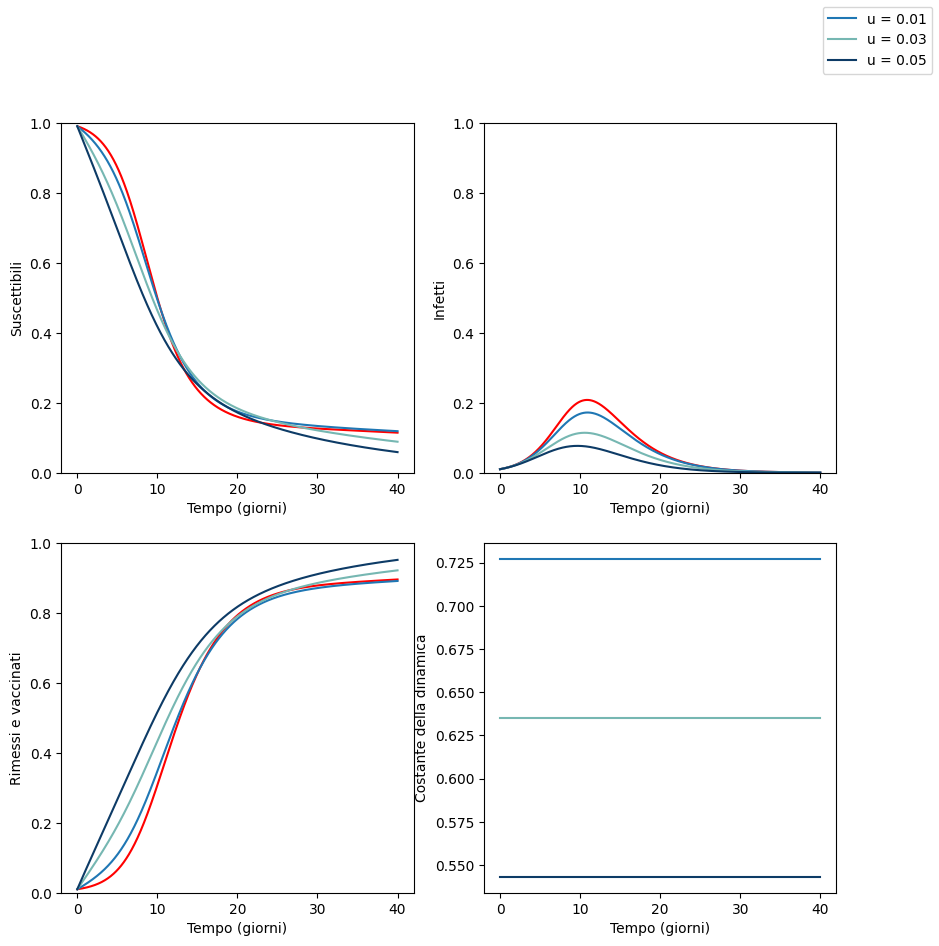

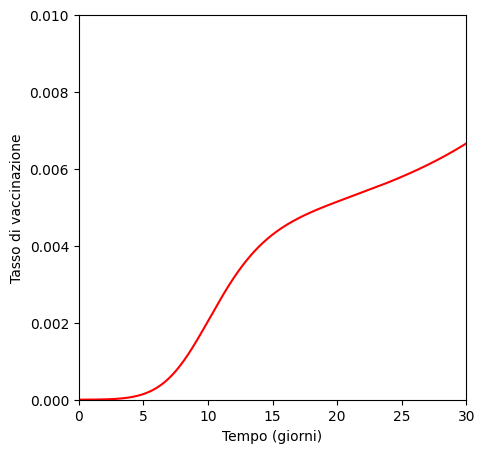

In [13]:
fig1, plot = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))
fig2, plot2 = plt.subplots(figsize = (5,5))

plot[0,0].set_xlabel('Tempo (giorni)')
plot[0,0].set_ylabel('Suscettibili')
plot[0,0].set_ylim([0,1])


plot[0,1].set_xlabel('Tempo (giorni)')
plot[0,1].set_ylabel('Infetti')
plot[0,1].set_ylim([0,1])

plot[1,0].set_xlabel('Tempo (giorni)')
plot[1,0].set_ylabel('Rimessi e vaccinati')
plot[1,0].set_ylim([0,1])

plot[1,1].set_xlabel('Tempo (giorni)')
plot[1,1].set_ylabel('Costante della dinamica')

plot2.set_xlabel('Tempo (giorni)')
plot2.set_ylabel('Tasso di vaccinazione')
plot2.set_ylim([0,0.01])
plot2.set_xlim([0,30])

t = np.linspace(0, 40, 1000)
steps_u = list(np.linspace(0.01, 0.05, 3)) #1000 vaccinati al giorno su 900000, frazione di vaccinati al giorno
index2 = list(np.arange(0, len(steps_u)))

solutions2 = []
s_true = []
i_true = []
r_true = []
times = []
us = []
areas = []
constant = []
colors =['#1f77b4', '#76b7b2', '#0d3b66']

for i in steps_u:
    m = 0.77
    u = i
    g = 1/3
    solution = (odeint(sol, [0.99,0.01,0.01], t))
    solutions2.append(solution)
    
    I = m * (solution.T[0] + solution.T[1]) + u * np.log(solution.T[1]) - g * np.log(solution.T[0])
    constant.append(I)
    
for solution in solutions2:
    index1 = np.where(solution.T[1] > 0)
    
    s_true.append(solution.T[0][index1])
    i_true.append(solution.T[1][index1])
    r_true.append(solution.T[2][index1])
    times.append(t[index1])
    

for j in index2:
    
    u_s = s_true[j] * u
    us.append(u_s)
    
    
plot[0,0].plot(t_true, values_S, c = 'r')
plot[0,1].plot(t_true, values_I, c = 'r')
plot[1,0].plot(t_true, values_R, c = 'r') 
plot2.plot(t_true, func_opt, c='r')  

for tempo, susc, inf, rec, const, color, u in zip(times, s_true, i_true, r_true, constant, colors, steps_u):
    plot[0,0].plot(tempo, susc, c = color, label = f'u = {u:.2f}')
    plot[0,1].plot(tempo, inf, c = color)
    plot[1,0].plot(tempo, rec, c = color)
    plot[1,1].plot(tempo, const, c = color)
    
fig1.legend(fontsize = 10)

fig1.savefig('vaccination.png')
fig2.savefig('vaccination2.png', bbox_inches='tight')
